**Set-Up Ambiente**

In [1]:
import subprocess
subprocess.run(["pip", "install", "-q", "--force-reinstall", "opencv-python-headless==4.9.0.80"])

CompletedProcess(args=['pip', 'install', '-q', '--force-reinstall', 'opencv-python-headless==4.9.0.80'], returncode=0)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -r /content/drive/MyDrive/FAIML-RL-26/requirements.txt -q

%cd /content/drive/MyDrive/FAIML-RL-26/part2/panda-gym
!pip install -e .

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/FAIML-RL-26/part2/panda-gym
Obtaining file:///content/drive/MyDrive/FAIML-RL-26/part2/panda-gym
  Preparing metadata (setup.py) ... done
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
  Attempting uninstall: panda_gym
    Found existing installation: panda_gym 3.0.8
    Uninstalling panda_gym-3.0.8:
      Successfully uninstalled panda_gym-3.0.8
  Running setup.py develop for panda_gym
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following depend

**Import necessari**

In [ ]:
import argparse
import os

import gymnasium as gym
import numpy as np
from stable_baselines3 import SAC
import panda_gym  # noqa: F401 - required so Panda envs are registered
import json
import matplotlib.pyplot as plt

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Evaluate**

In [ ]:
def evaluate(model_path: str, n_episodes: int, deterministic: bool, render: bool, env_type: str, env_training: str) -> None:
    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"Model file not found: {model_path}. "
            "Make sure you saved your trained model with model.save(...)."
        )

    render_mode = "human" if render else "rgb_array"
    env = gym.make("PandaPush-v3", render_mode=render_mode, type=env_type, reward_type="dense")
    #TODO: load model here
    model = SAC.load(model_path)

    episode_returns = []
    successes = []

    for episode in range(1, n_episodes + 1):
        obs, info = env.reset(seed=42 + episode)
        terminated = False
        truncated = False
        episode_return = 0.0

        while not (terminated or truncated):
            action,_ = model.predict(obs, deterministic=deterministic) #TODO: get action from the model
            obs, reward, terminated, truncated, info = env.step(action)
            episode_return += float(reward)

        episode_returns.append(episode_return)

        if isinstance(info, dict) and "is_success" in info:
            successes.append(float(info["is_success"]))

        print(f"Episode {episode:03d} | return = {episode_return:.3f}")

    env.close()

    returns = np.array(episode_returns, dtype=np.float32)
    print("\n=== Evaluation summary ===")
    print(f"Episodes: {n_episodes}")
    print(f"Mean return: {returns.mean():.3f}")
    print(f"Std return:  {returns.std():.3f}")
    print(f"Min return:  {returns.min():.3f}")
    print(f"Max return:  {returns.max():.3f}")

    if successes:
        success_rate = float(np.mean(successes))
        print(f"Success rate: {success_rate:.2%}")

    #Aggiunta
    results = {
      "model": model_path,
      "env_type": env_type,
      "n_episodes": n_episodes,
      "mean_return": float(returns.mean()),
      "std_return": float(returns.std()),
      "min_return": float(returns.min()),
      "max_return": float(returns.max()),
      "success_rate": float(np.mean(successes)) if successes else None
    }
    with open(f"/content/drive/MyDrive/FAIML-RL-26/results/eval_{env_training}_model/eval_{env_type}.json", "w") as f:
        json.dump(results, f, indent=2)

    plt.figure(figsize=(8, 4))
    plt.hist(episode_returns, bins=20, color='#534AB7', edgecolor='white')
    plt.axvline(returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.2f}')
    plt.xlabel('Episode return')
    plt.ylabel('Count')
    plt.title(f'Return distribution — Evaluation on {env_type} - Training on {env_training}')
    plt.legend()
    plt.savefig(f"/content/drive/MyDrive/FAIML-RL-26/results/eval_{env_training}_model/eval_{env_type}.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(range(1, n_episodes + 1), episode_returns, color='#534AB7', linewidth=1.5)
    plt.axhline(returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.2f}')
    plt.xlabel('Episode')
    plt.ylabel('Return')
    plt.title(f'Return per episode — Evaluation on {env_type} - Training on {env_training}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f"/content/drive/MyDrive/FAIML-RL-26/results/eval_{env_training}_model/eval_{env_type}_per_episode.png", dpi=150)
    plt.show()

    cumulative_success = np.cumsum(successes) / np.arange(1, len(successes) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(range(1, len(successes) + 1), cumulative_success, color='#0F6E56', linewidth=1.5)
    plt.axhline(np.mean(successes), color='red', linestyle='--', label=f'Final: {np.mean(successes):.2%}')
    plt.xlabel('Episode')
    plt.ylabel('Cumulative success rate')
    plt.title(f'Cumulative success rate — Evaluation on {env_type} - Training on {env_training}')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f"/content/drive/MyDrive/FAIML-RL-26/results/eval_{env_training}_model/eval_{env_type}_success_rate.png", dpi=150)
    plt.show()

**Parse_args (non mi serve)**

In [ ]:
def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Evaluate SAC on PandaPush-v3")
    parser.add_argument(
        "--model-path",
        type=str,
        required=True,
        help="Path to a PPO model zip file (e.g., ppo_panda_push.zip)",
    )
    parser.add_argument(
        "--episodes",
        type=int,
        default=500,
        help="Number of eval episodes"
    )
    parser.add_argument(
        "--stochastic",
        action="store_true",
        help="Use stochastic policy sampling instead of deterministic actions",
    )
    parser.add_argument(
        "--render",
        action="store_true",
        help="Render with a window (render_mode='human')",
    )
    parser.add_argument(
        "--env-type",
        type=str, default="target",
        choices=["source", "target"],
        help="Type of environment to evaluate on (default: target)",
    )
    return parser.parse_args()

**Main source-source**

Created object with mass: 1.0
Episode 001 | return = -3.920
Episode 002 | return = -1.099
Episode 003 | return = -0.016
Episode 004 | return = -0.942
Episode 005 | return = -0.515
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.713
Episode 009 | return = -1.667
Episode 010 | return = -0.028
Episode 011 | return = -1.560
Episode 012 | return = -0.534
Episode 013 | return = -0.886
Episode 014 | return = -0.628
Episode 015 | return = -0.037
Episode 016 | return = -2.078
Episode 017 | return = -0.372
Episode 018 | return = -1.396
Episode 019 | return = -3.060
Episode 020 | return = -0.784
Episode 021 | return = -4.961
Episode 022 | return = -0.487
Episode 023 | return = -4.530
Episode 024 | return = -0.748
Episode 025 | return = -0.837
Episode 026 | return = -0.398
Episode 027 | return = -0.017
Episode 028 | return = -0.454
Episode 029 | return = -0.050
Episode 030 | return = -0.888
Episode 031 | return = -0.039
Episode 032 | return = -0.422
Episode 03

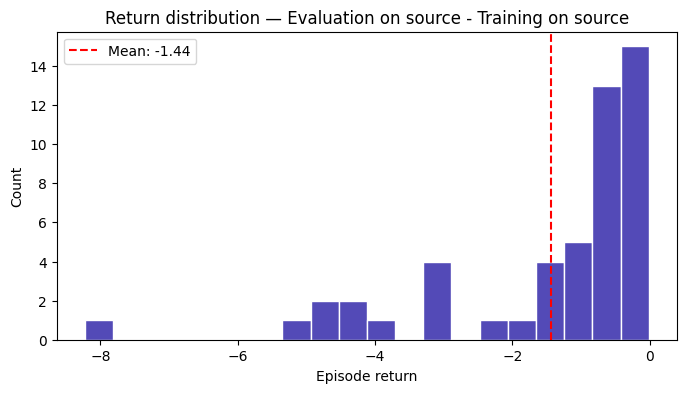

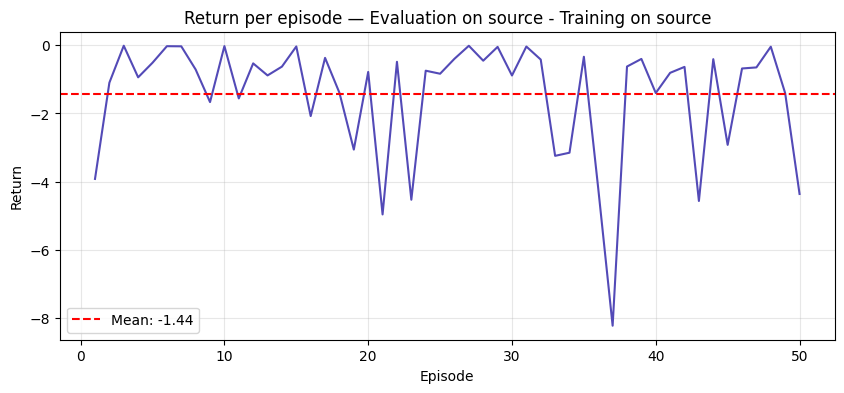

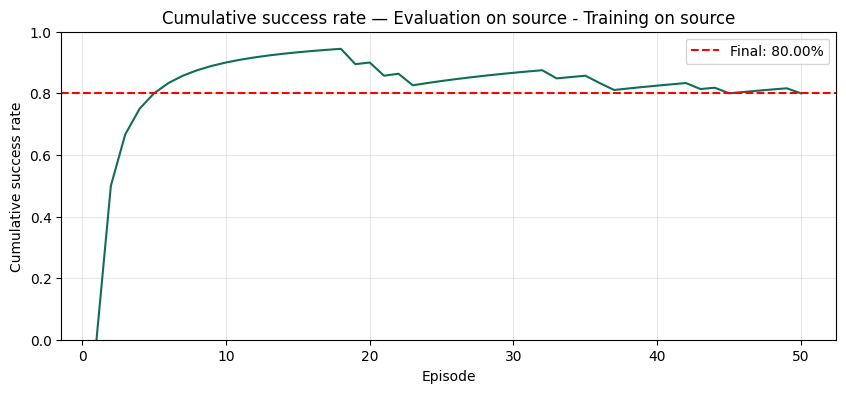

In [ ]:
if __name__ == "__main__":
    #args = parse_args()
    evaluate(
        model_path="/content/drive/MyDrive/FAIML-RL-26/results/sac_source/sac_push_none_source_500000_batchsize.zip", #args.model_path,
        n_episodes=50, #args.episodes,
        deterministic= True, #not args.stochastic,
        render=False, #args.render,
        env_type="source", #args.env_type,
        env_training = "source",
    )

**Main source-target**

Created object with mass: 5.0
Episode 001 | return = -4.118
Episode 002 | return = -1.170
Episode 003 | return = -0.016
Episode 004 | return = -1.941
Episode 005 | return = -0.525
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.689
Episode 009 | return = -3.902
Episode 010 | return = -0.028
Episode 011 | return = -1.593
Episode 012 | return = -0.541
Episode 013 | return = -1.005
Episode 014 | return = -0.725
Episode 015 | return = -0.037
Episode 016 | return = -1.198
Episode 017 | return = -2.538
Episode 018 | return = -1.438
Episode 019 | return = -0.880
Episode 020 | return = -0.806
Episode 021 | return = -4.898
Episode 022 | return = -0.540
Episode 023 | return = -4.528
Episode 024 | return = -0.767
Episode 025 | return = -0.866
Episode 026 | return = -0.696
Episode 027 | return = -0.017
Episode 028 | return = -0.502
Episode 029 | return = -0.050
Episode 030 | return = -1.171
Episode 031 | return = -0.039
Episode 032 | return = -0.442
Episode 03

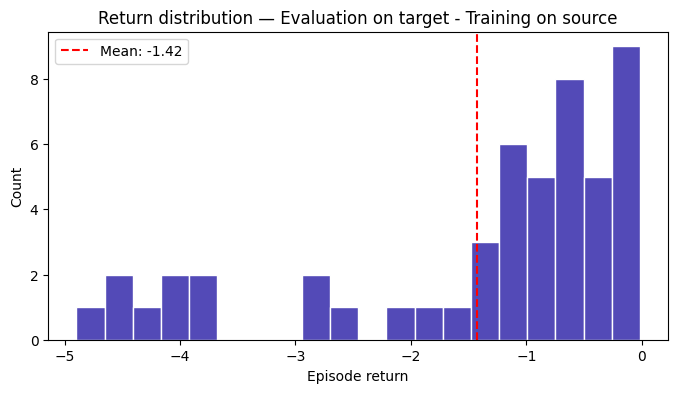

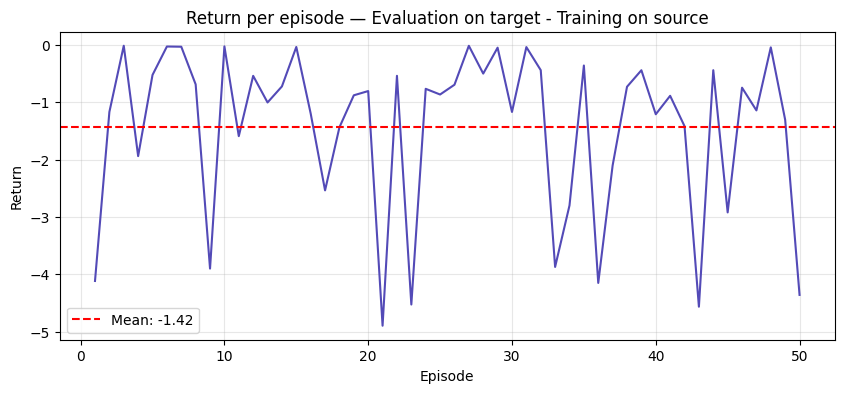

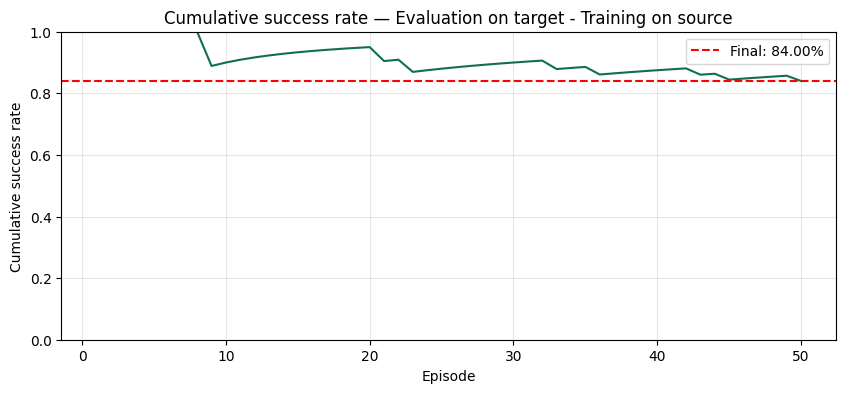

In [ ]:
if __name__ == "__main__":
    #args = parse_args()
    evaluate(
        model_path="/content/drive/MyDrive/FAIML-RL-26/results/sac_source/sac_push_none_source_500000_batchsize.zip", #args.model_path,
        n_episodes=50, #args.episodes,
        deterministic= True, #not args.stochastic,
        render=False, #args.render,
        env_type="target", #args.env_type,
        env_training = "source",
    )

**Main target-target**

Created object with mass: 5.0
Episode 001 | return = -0.696
Episode 002 | return = -0.649
Episode 003 | return = -0.016
Episode 004 | return = -1.669
Episode 005 | return = -0.316
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.449
Episode 009 | return = -0.551
Episode 010 | return = -0.028
Episode 011 | return = -1.036
Episode 012 | return = -0.372
Episode 013 | return = -0.572
Episode 014 | return = -0.979
Episode 015 | return = -0.037
Episode 016 | return = -0.509
Episode 017 | return = -0.362
Episode 018 | return = -0.802
Episode 019 | return = -0.284
Episode 020 | return = -0.256
Episode 021 | return = -0.694
Episode 022 | return = -0.465
Episode 023 | return = -0.754
Episode 024 | return = -0.539
Episode 025 | return = -0.610
Episode 026 | return = -0.396
Episode 027 | return = -0.017
Episode 028 | return = -0.201
Episode 029 | return = -0.050
Episode 030 | return = -1.014
Episode 031 | return = -0.039
Episode 032 | return = -0.426
Episode 03

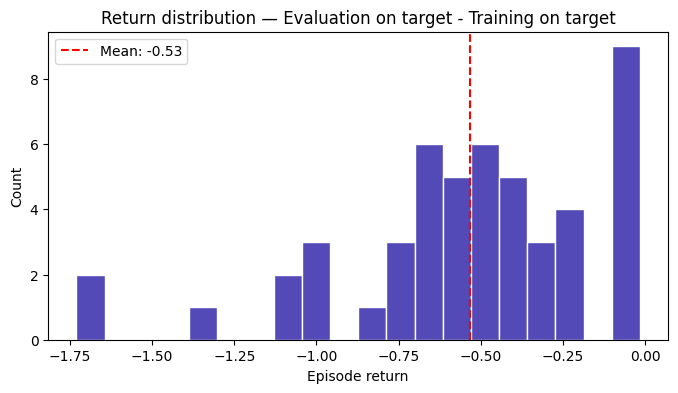

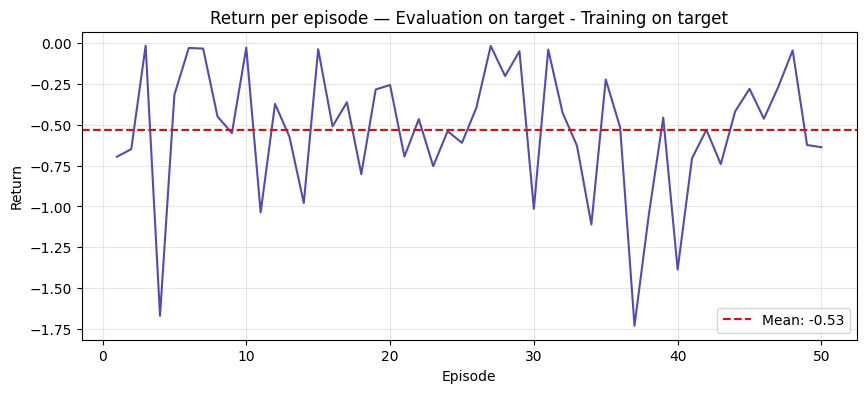

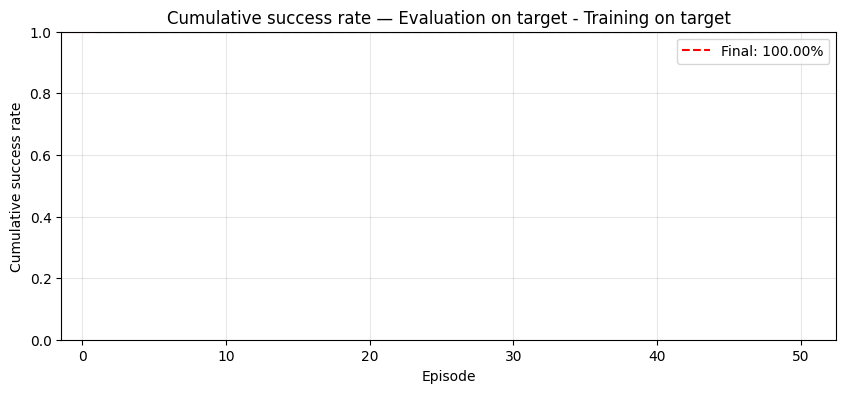

In [ ]:
if __name__ == "__main__":
    #args = parse_args()
    evaluate(
        model_path="/content/drive/MyDrive/FAIML-RL-26/results/sac_target/sac_push_none_target_500000.zip", #args.model_path,
        n_episodes=50, #args.episodes,
        deterministic= True, #not args.stochastic,
        render=False, #args.render,
        env_type="target", #args.env_type,
        env_training = "target",
    )

**Sensitivity Analysis**

In [ ]:
def evaluate(model_path: str, n_episodes: int, deterministic: bool, render: bool, env_type: str, env_training: str, target_mass: float = None) -> None:
    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"Model file not found: {model_path}. "
            "Make sure you saved your trained model with model.save(...)."
        )

    render_mode = "human" if render else "rgb_array"
    env = gym.make("PandaPush-v3", render_mode=render_mode, type=env_type, reward_type="dense")

    if target_mass is not None:
      sim = env.unwrapped.task.sim
      object_body_id = sim._bodies_idx["object"]
      sim.physics_client.changeDynamics(
          bodyUniqueId=object_body_id,
          linkIndex=-1,
          mass=float(target_mass)
      )

    #TODO: load model here
    model = SAC.load(model_path)

    episode_returns = []
    successes = []

    for episode in range(1, n_episodes + 1):
        obs, info = env.reset(seed=42 + episode)
        terminated = False
        truncated = False
        episode_return = 0.0

        while not (terminated or truncated):
            action,_ = model.predict(obs, deterministic=deterministic) #TODO: get action from the model
            obs, reward, terminated, truncated, info = env.step(action)
            episode_return += float(reward)

        episode_returns.append(episode_return)

        if isinstance(info, dict) and "is_success" in info:
            successes.append(float(info["is_success"]))

        print(f"Episode {episode:03d} | return = {episode_return:.3f}")

    env.close()

    returns = np.array(episode_returns, dtype=np.float32)
    print("\n=== Evaluation summary ===")
    print(f"Episodes: {n_episodes}")
    print(f"Mean return: {returns.mean():.3f}")
    print(f"Std return:  {returns.std():.3f}")
    print(f"Min return:  {returns.min():.3f}")
    print(f"Max return:  {returns.max():.3f}")

    if successes:
        success_rate = float(np.mean(successes))
        print(f"Success rate: {success_rate:.2%}")

    mass_suffix = f"_mass{target_mass}" if target_mass is not None else ""

    #Aggiunta
    results = {
      "model": model_path,
      "env_type": env_type,
      "n_episodes": n_episodes,
      "target_mass": target_mass,
      "mean_return": float(returns.mean()),
      "std_return": float(returns.std()),
      "min_return": float(returns.min()),
      "max_return": float(returns.max()),
      "success_rate": float(np.mean(successes)) if successes else None
    }
    with open(f"/content/drive/MyDrive/FAIML-RL-26/results/eval_sensitivity/eval{mass_suffix}.json", "w") as f:
        json.dump(results, f, indent=2)

    plt.figure(figsize=(8, 4))
    plt.hist(episode_returns, bins=20, color='#534AB7', edgecolor='white')
    plt.axvline(returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.2f}')
    plt.xlabel('Episode return')
    plt.ylabel('Count')
    plt.title(f'Return distribution — Evaluation on {env_type} - Training on {env_training}{" mass=" + str(target_mass) if target_mass else ""}')
    plt.legend()
    plt.savefig(f"/content/drive/MyDrive/FAIML-RL-26/results/eval_sensitivity/eval{mass_suffix}.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(range(1, n_episodes + 1), episode_returns, color='#534AB7', linewidth=1.5)
    plt.axhline(returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.2f}')
    plt.xlabel('Episode')
    plt.ylabel('Return')
    plt.title(f'Return per episode — Evaluation on {env_type} - Training on {env_training}{" mass=" + str(target_mass) if target_mass else ""}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f"/content/drive/MyDrive/FAIML-RL-26/results/eval_sensitivity/eval{mass_suffix}_per_episode.png", dpi=150)
    plt.show()

    cumulative_success = np.cumsum(successes) / np.arange(1, len(successes) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(range(1, len(successes) + 1), cumulative_success, color='#0F6E56', linewidth=1.5)
    plt.axhline(np.mean(successes), color='red', linestyle='--', label=f'Final: {np.mean(successes):.2%}')
    plt.xlabel('Episode')
    plt.ylabel('Cumulative success rate')
    plt.title(f'Cumulative success rate — Evaluation on {env_type} - Training on {env_training}{" mass=" + str(target_mass) if target_mass else ""}')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f"/content/drive/MyDrive/FAIML-RL-26/results/eval_sensitivity/eval{mass_suffix}_success_rate.png", dpi=150)
    plt.show()

Created object with mass: 5.0
Episode 001 | return = -3.920
Episode 002 | return = -1.099
Episode 003 | return = -0.016
Episode 004 | return = -0.942
Episode 005 | return = -0.515
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.713
Episode 009 | return = -1.667
Episode 010 | return = -0.028
Episode 011 | return = -1.560
Episode 012 | return = -0.534
Episode 013 | return = -0.886
Episode 014 | return = -0.628
Episode 015 | return = -0.037
Episode 016 | return = -2.078
Episode 017 | return = -0.372
Episode 018 | return = -1.396
Episode 019 | return = -3.060
Episode 020 | return = -0.784
Episode 021 | return = -4.961
Episode 022 | return = -0.487
Episode 023 | return = -4.530
Episode 024 | return = -0.748
Episode 025 | return = -0.837
Episode 026 | return = -0.398
Episode 027 | return = -0.017
Episode 028 | return = -0.454
Episode 029 | return = -0.050
Episode 030 | return = -0.888
Episode 031 | return = -0.039
Episode 032 | return = -0.422
Episode 03

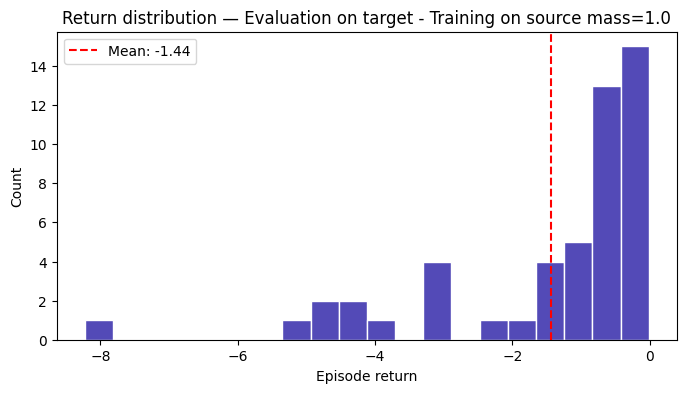

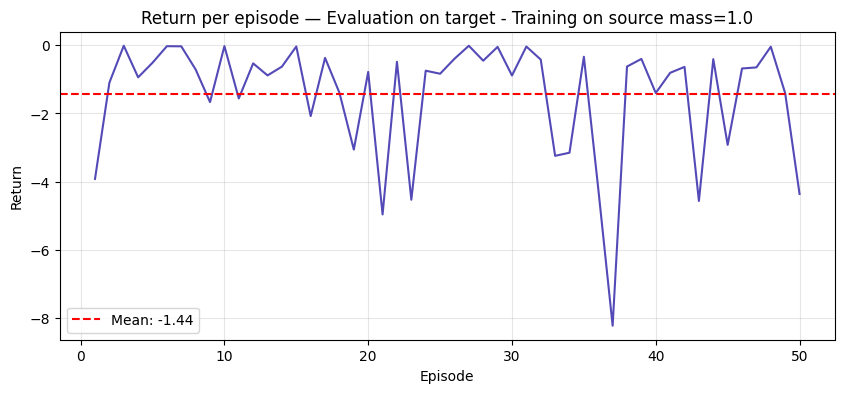

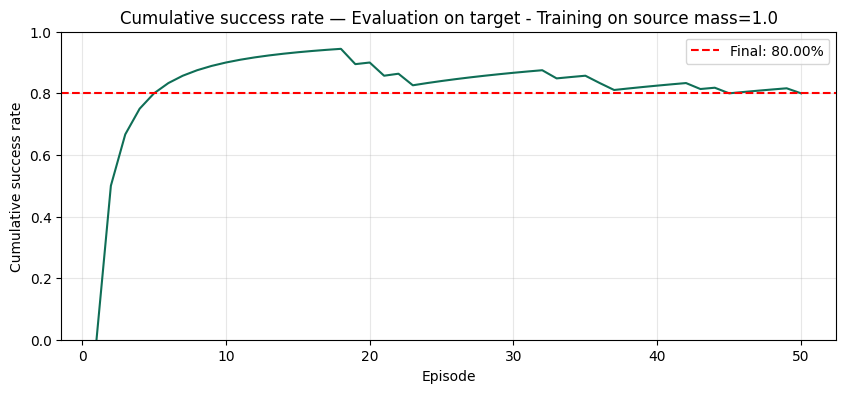

Created object with mass: 5.0
Episode 001 | return = -4.052
Episode 002 | return = -1.152
Episode 003 | return = -0.016
Episode 004 | return = -1.008
Episode 005 | return = -0.517
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.718
Episode 009 | return = -5.001
Episode 010 | return = -0.028
Episode 011 | return = -1.566
Episode 012 | return = -0.536
Episode 013 | return = -0.942
Episode 014 | return = -0.648
Episode 015 | return = -0.037
Episode 016 | return = -3.226
Episode 017 | return = -0.378
Episode 018 | return = -1.409
Episode 019 | return = -0.875
Episode 020 | return = -0.795
Episode 021 | return = -4.637
Episode 022 | return = -0.518
Episode 023 | return = -4.528
Episode 024 | return = -0.751
Episode 025 | return = -0.846
Episode 026 | return = -0.452
Episode 027 | return = -0.017
Episode 028 | return = -0.455
Episode 029 | return = -0.050
Episode 030 | return = -1.039
Episode 031 | return = -0.039
Episode 032 | return = -0.473
Episode 03

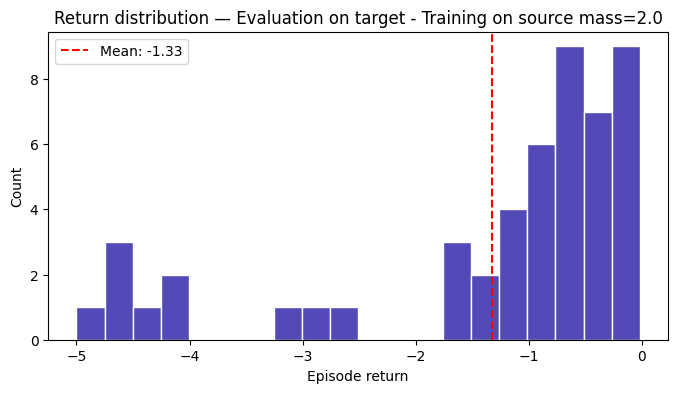

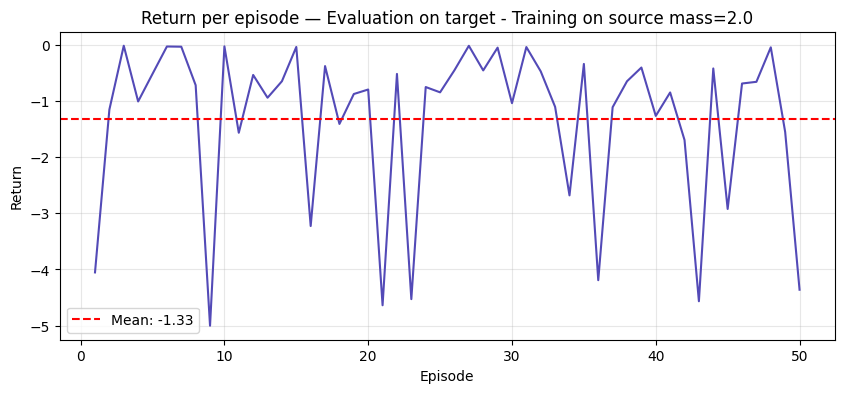

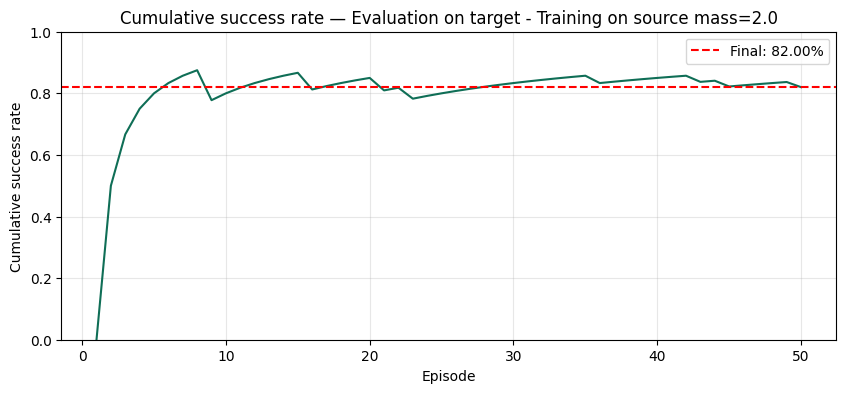

Created object with mass: 5.0
Episode 001 | return = -2.397
Episode 002 | return = -1.157
Episode 003 | return = -0.016
Episode 004 | return = -1.027
Episode 005 | return = -0.521
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.697
Episode 009 | return = -3.544
Episode 010 | return = -0.028
Episode 011 | return = -1.571
Episode 012 | return = -0.538
Episode 013 | return = -0.947
Episode 014 | return = -0.665
Episode 015 | return = -0.037
Episode 016 | return = -1.982
Episode 017 | return = -2.724
Episode 018 | return = -1.416
Episode 019 | return = -0.877
Episode 020 | return = -0.801
Episode 021 | return = -5.364
Episode 022 | return = -0.517
Episode 023 | return = -4.531
Episode 024 | return = -0.760
Episode 025 | return = -0.855
Episode 026 | return = -0.512
Episode 027 | return = -0.017
Episode 028 | return = -0.455
Episode 029 | return = -0.050
Episode 030 | return = -1.264
Episode 031 | return = -0.039
Episode 032 | return = -0.439
Episode 03

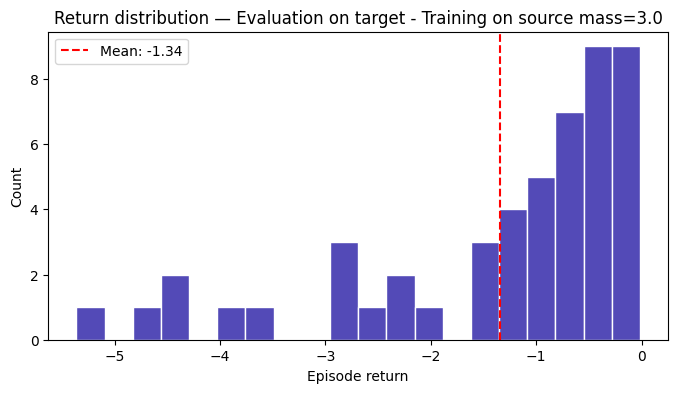

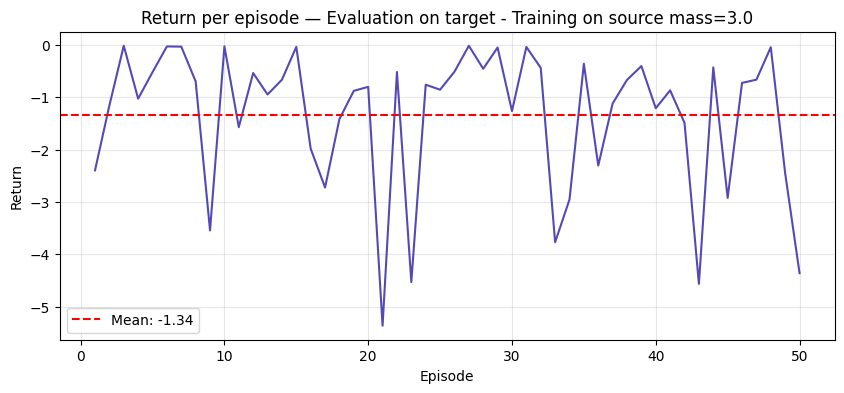

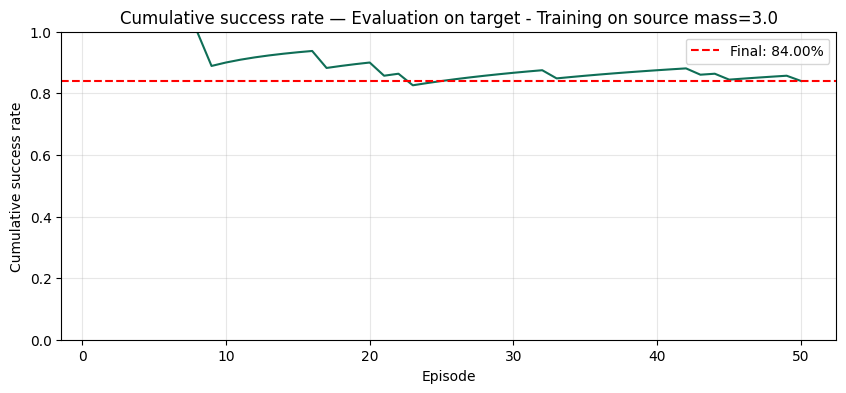

Created object with mass: 5.0
Episode 001 | return = -2.190
Episode 002 | return = -1.164
Episode 003 | return = -0.016
Episode 004 | return = -1.092
Episode 005 | return = -0.523
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.687
Episode 009 | return = -3.834
Episode 010 | return = -0.028
Episode 011 | return = -1.578
Episode 012 | return = -0.539
Episode 013 | return = -0.954
Episode 014 | return = -0.714
Episode 015 | return = -0.037
Episode 016 | return = -3.744
Episode 017 | return = -1.048
Episode 018 | return = -1.426
Episode 019 | return = -0.936
Episode 020 | return = -0.803
Episode 021 | return = -4.472
Episode 022 | return = -0.525
Episode 023 | return = -4.528
Episode 024 | return = -0.756
Episode 025 | return = -0.862
Episode 026 | return = -0.793
Episode 027 | return = -0.017
Episode 028 | return = -0.500
Episode 029 | return = -0.050
Episode 030 | return = -1.224
Episode 031 | return = -0.039
Episode 032 | return = -0.439
Episode 03

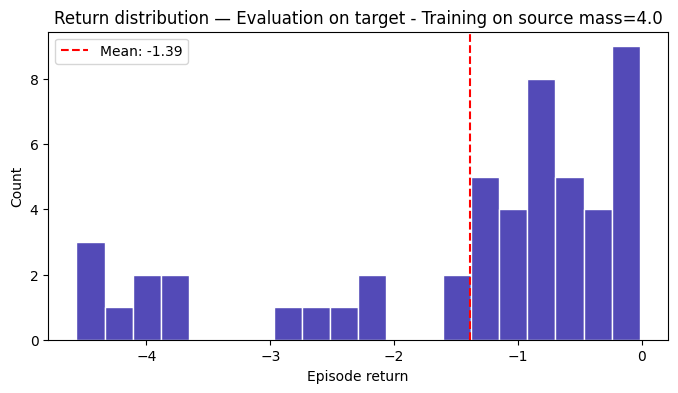

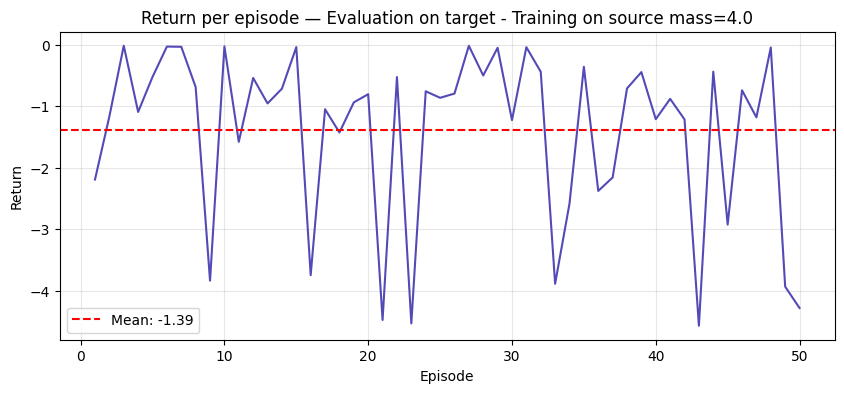

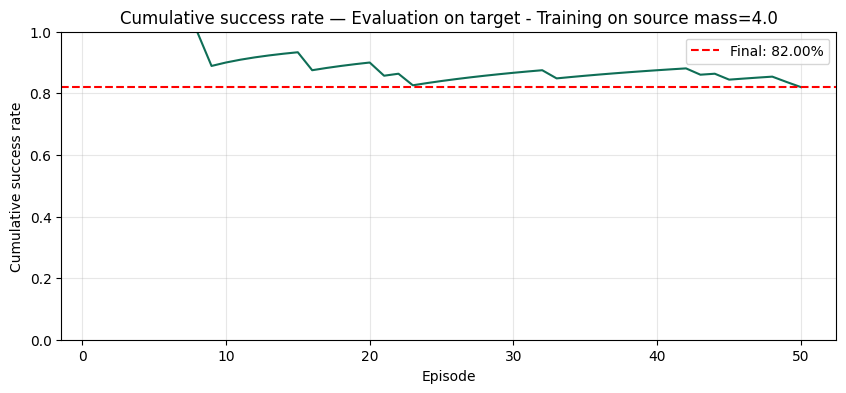

Created object with mass: 5.0
Episode 001 | return = -4.118
Episode 002 | return = -1.170
Episode 003 | return = -0.016
Episode 004 | return = -1.941
Episode 005 | return = -0.525
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.689
Episode 009 | return = -3.902
Episode 010 | return = -0.028
Episode 011 | return = -1.593
Episode 012 | return = -0.541
Episode 013 | return = -1.005
Episode 014 | return = -0.725
Episode 015 | return = -0.037
Episode 016 | return = -1.198
Episode 017 | return = -2.538
Episode 018 | return = -1.438
Episode 019 | return = -0.880
Episode 020 | return = -0.806
Episode 021 | return = -4.898
Episode 022 | return = -0.540
Episode 023 | return = -4.528
Episode 024 | return = -0.767
Episode 025 | return = -0.866
Episode 026 | return = -0.696
Episode 027 | return = -0.017
Episode 028 | return = -0.502
Episode 029 | return = -0.050
Episode 030 | return = -1.171
Episode 031 | return = -0.039
Episode 032 | return = -0.442
Episode 03

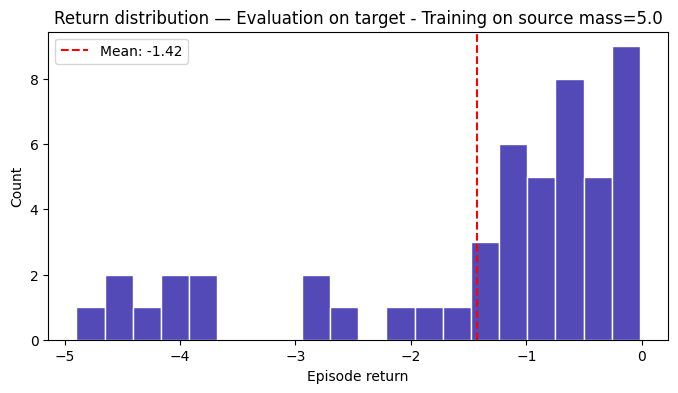

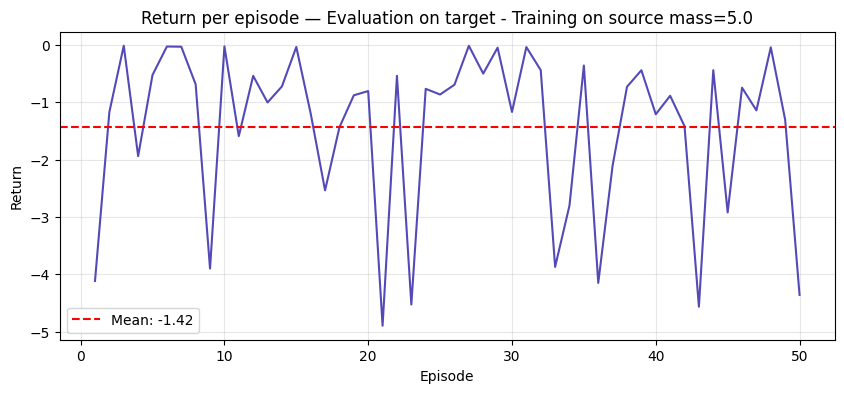

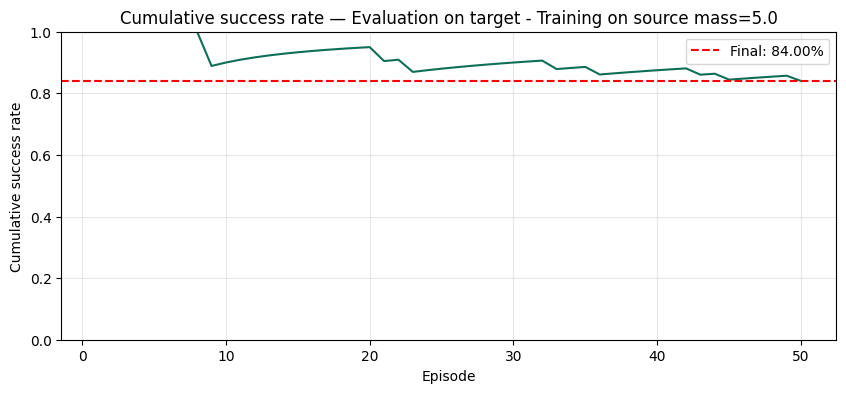

Created object with mass: 5.0
Episode 001 | return = -2.128
Episode 002 | return = -1.178
Episode 003 | return = -0.016
Episode 004 | return = -2.918
Episode 005 | return = -0.520
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.702
Episode 009 | return = -3.920
Episode 010 | return = -0.028
Episode 011 | return = -1.607
Episode 012 | return = -0.542
Episode 013 | return = -0.950
Episode 014 | return = -0.728
Episode 015 | return = -0.037
Episode 016 | return = -1.225
Episode 017 | return = -3.353
Episode 018 | return = -1.443
Episode 019 | return = -0.881
Episode 020 | return = -0.807
Episode 021 | return = -4.948
Episode 022 | return = -0.545
Episode 023 | return = -4.528
Episode 024 | return = -0.767
Episode 025 | return = -0.872
Episode 026 | return = -3.106
Episode 027 | return = -0.017
Episode 028 | return = -0.502
Episode 029 | return = -0.050
Episode 030 | return = -1.539
Episode 031 | return = -0.039
Episode 032 | return = -0.444
Episode 03

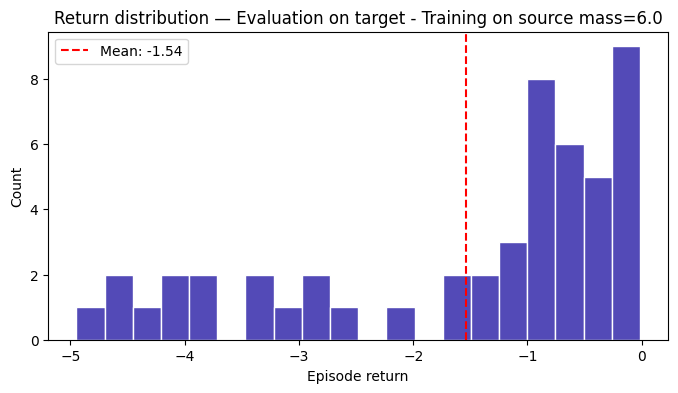

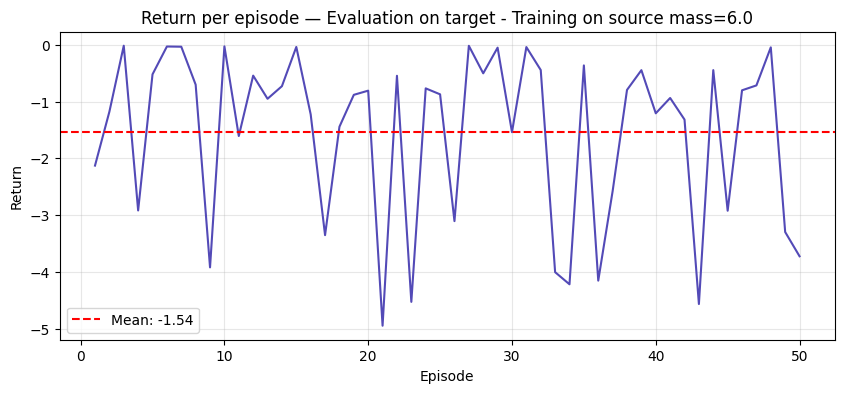

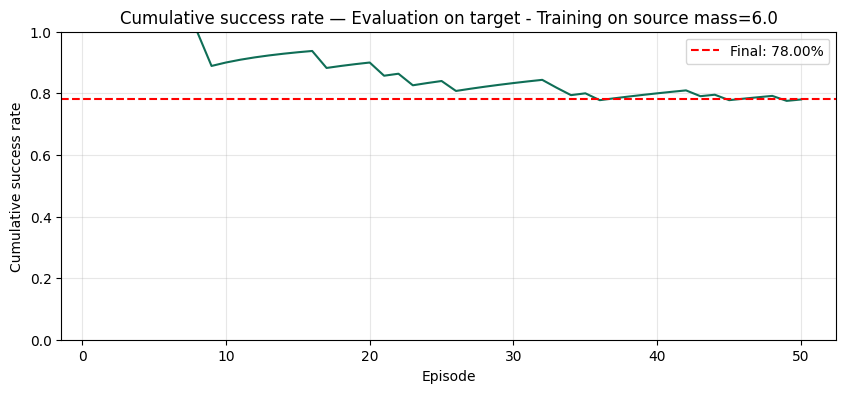

Created object with mass: 5.0
Episode 001 | return = -4.006
Episode 002 | return = -1.225
Episode 003 | return = -0.016
Episode 004 | return = -2.461
Episode 005 | return = -0.523
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.710
Episode 009 | return = -3.997
Episode 010 | return = -0.028
Episode 011 | return = -1.666
Episode 012 | return = -0.544
Episode 013 | return = -0.956
Episode 014 | return = -0.796
Episode 015 | return = -0.037
Episode 016 | return = -1.213
Episode 017 | return = -1.140
Episode 018 | return = -1.478
Episode 019 | return = -0.882
Episode 020 | return = -0.857
Episode 021 | return = -4.939
Episode 022 | return = -0.540
Episode 023 | return = -4.531
Episode 024 | return = -0.773
Episode 025 | return = -0.873
Episode 026 | return = -0.707
Episode 027 | return = -0.017
Episode 028 | return = -0.504
Episode 029 | return = -0.050
Episode 030 | return = -2.161
Episode 031 | return = -0.039
Episode 032 | return = -0.469
Episode 03

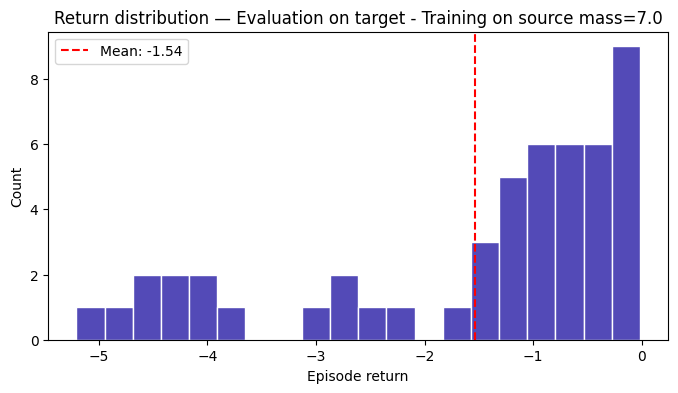

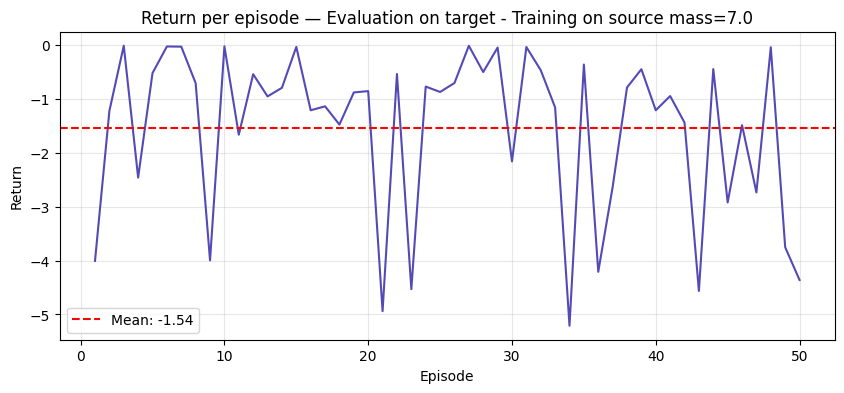

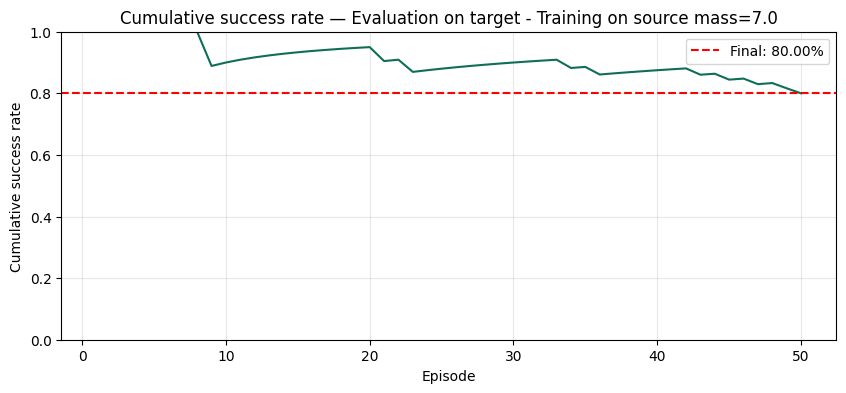

Created object with mass: 5.0
Episode 001 | return = -3.898
Episode 002 | return = -1.235
Episode 003 | return = -0.016
Episode 004 | return = -2.492
Episode 005 | return = -0.524
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.719
Episode 009 | return = -4.334
Episode 010 | return = -0.028
Episode 011 | return = -1.677
Episode 012 | return = -0.545
Episode 013 | return = -1.020
Episode 014 | return = -0.869
Episode 015 | return = -0.037
Episode 016 | return = -1.260
Episode 017 | return = -1.038
Episode 018 | return = -1.490
Episode 019 | return = -0.883
Episode 020 | return = -2.561
Episode 021 | return = -4.968
Episode 022 | return = -0.545
Episode 023 | return = -4.531
Episode 024 | return = -0.774
Episode 025 | return = -0.876
Episode 026 | return = -0.714
Episode 027 | return = -0.017
Episode 028 | return = -0.504
Episode 029 | return = -0.050
Episode 030 | return = -3.800
Episode 031 | return = -0.039
Episode 032 | return = -0.474
Episode 03

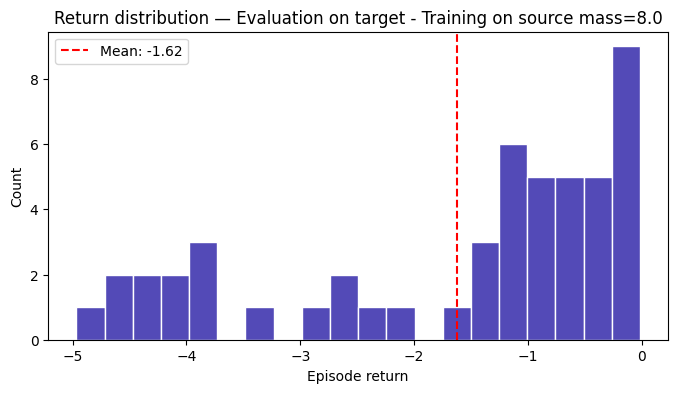

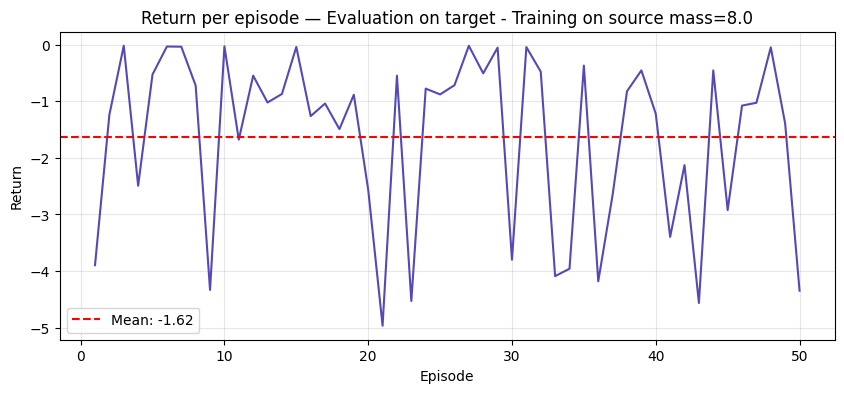

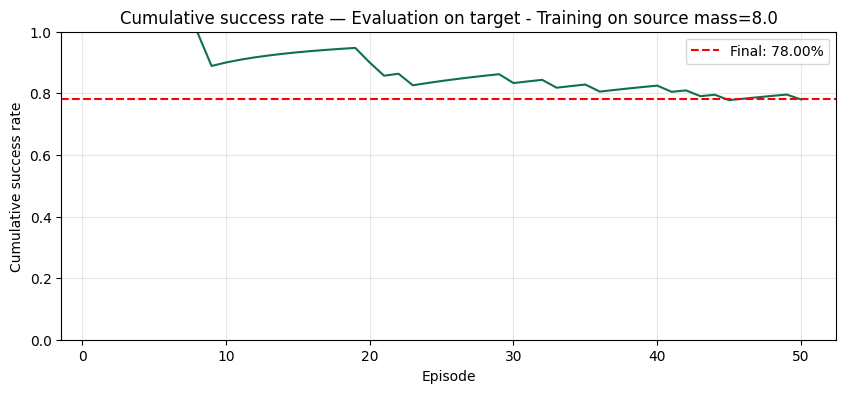

Created object with mass: 5.0
Episode 001 | return = -1.744
Episode 002 | return = -1.296
Episode 003 | return = -0.016
Episode 004 | return = -4.114
Episode 005 | return = -0.526
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.724
Episode 009 | return = -2.595
Episode 010 | return = -0.028
Episode 011 | return = -1.737
Episode 012 | return = -0.546
Episode 013 | return = -1.076
Episode 014 | return = -0.883
Episode 015 | return = -0.037
Episode 016 | return = -1.263
Episode 017 | return = -3.259
Episode 018 | return = -1.516
Episode 019 | return = -0.885
Episode 020 | return = -2.605
Episode 021 | return = -4.941
Episode 022 | return = -0.551
Episode 023 | return = -4.530
Episode 024 | return = -0.778
Episode 025 | return = -0.919
Episode 026 | return = -0.722
Episode 027 | return = -0.017
Episode 028 | return = -0.505
Episode 029 | return = -0.050
Episode 030 | return = -4.090
Episode 031 | return = -0.039
Episode 032 | return = -0.480
Episode 03

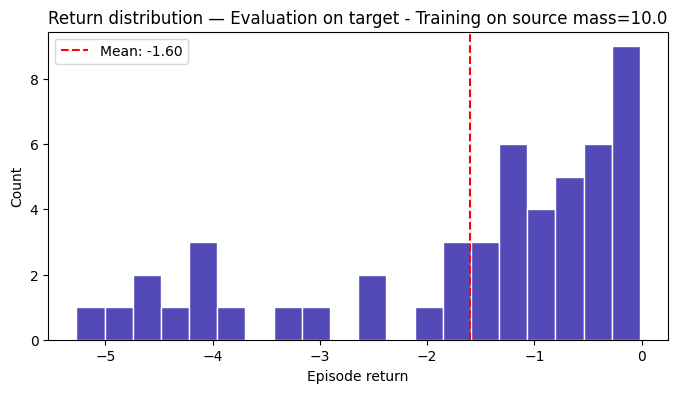

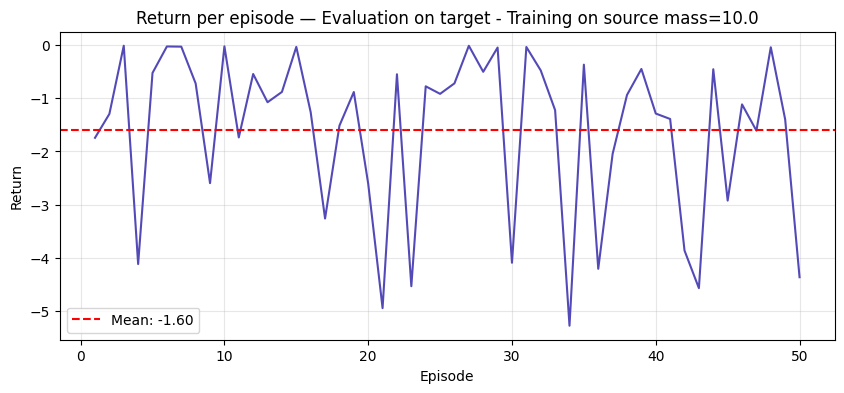

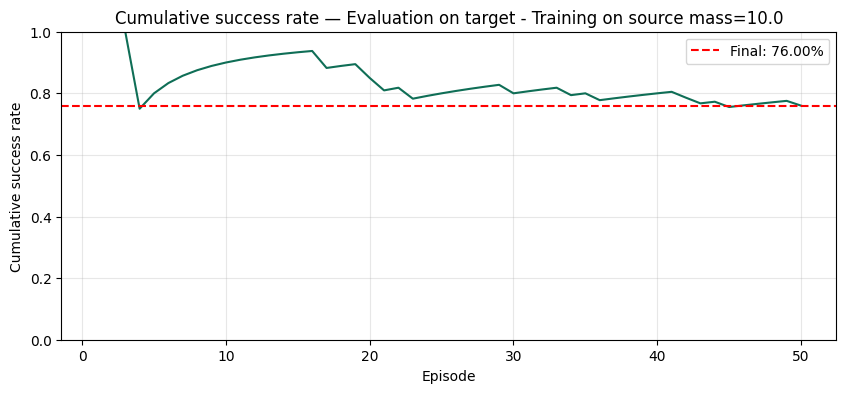

Created object with mass: 5.0
Episode 001 | return = -3.556
Episode 002 | return = -3.214
Episode 003 | return = -0.016
Episode 004 | return = -4.083
Episode 005 | return = -0.529
Episode 006 | return = -0.030
Episode 007 | return = -0.033
Episode 008 | return = -0.735
Episode 009 | return = -3.733
Episode 010 | return = -0.028
Episode 011 | return = -3.555
Episode 012 | return = -0.548
Episode 013 | return = -3.104
Episode 014 | return = -3.443
Episode 015 | return = -0.037
Episode 016 | return = -1.356
Episode 017 | return = -3.333
Episode 018 | return = -1.579
Episode 019 | return = -0.937
Episode 020 | return = -2.593
Episode 021 | return = -4.853
Episode 022 | return = -0.557
Episode 023 | return = -4.528
Episode 024 | return = -0.806
Episode 025 | return = -0.926
Episode 026 | return = -0.775
Episode 027 | return = -0.017
Episode 028 | return = -0.506
Episode 029 | return = -0.050
Episode 030 | return = -3.626
Episode 031 | return = -0.039
Episode 032 | return = -0.482
Episode 03

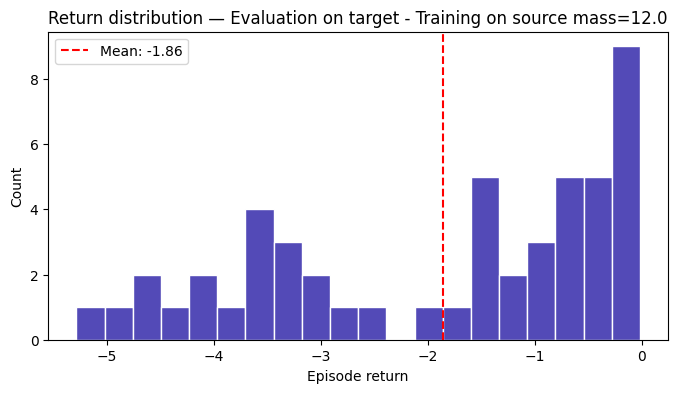

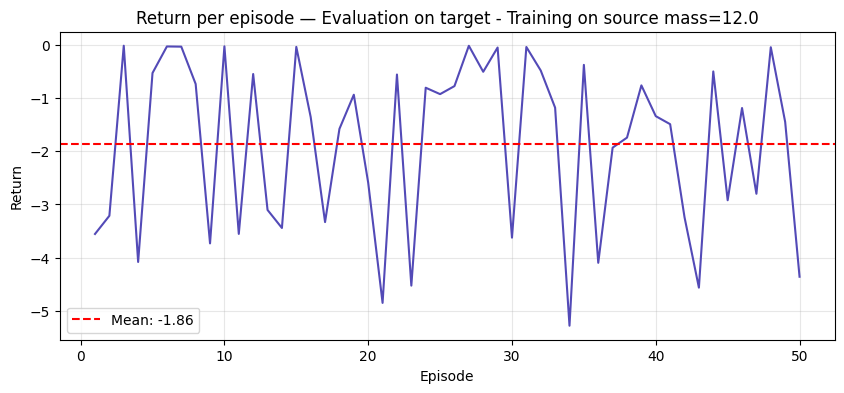

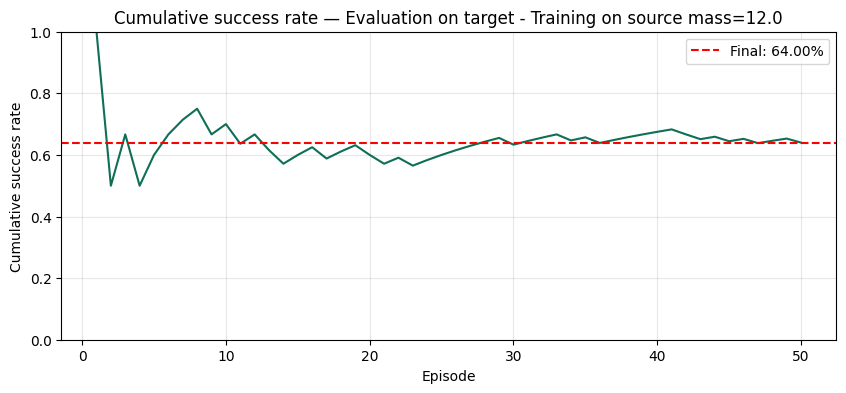

In [ ]:
if __name__ == "__main__":
    #args = parse_args()
    for massa in [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0]:
      evaluate(
          model_path="/content/drive/MyDrive/FAIML-RL-26/results/sac_source/sac_push_none_source_500000_batchsize.zip", #args.model_path,
          n_episodes=50, #args.episodes,
          deterministic= True, #not args.stochastic,
          render=False, #args.render,
          env_type="target", #args.env_type,
          env_training = "source",
          target_mass=massa,
      )

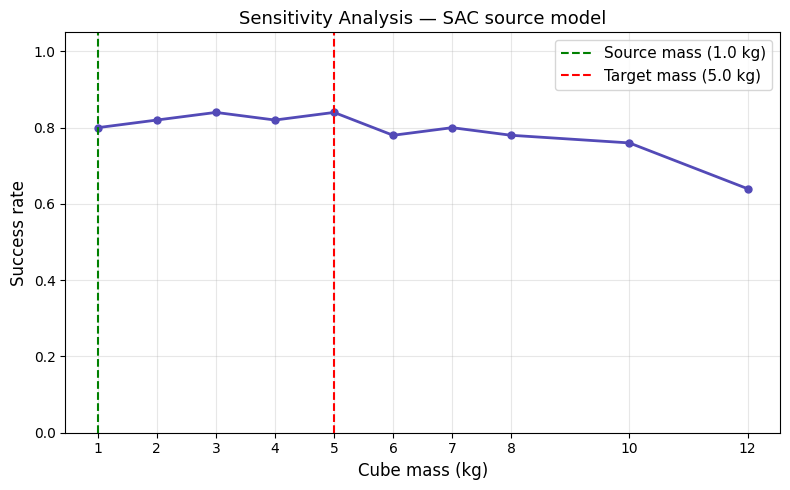

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# masse testate
masse = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0]

# success rate corrispondenti
success_rates = [0.80, 0.82, 0.84, 0.82, 0.84, 0.78, 0.80, 0.78, 0.76, 0.64]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(masse, success_rates, color='#534AB7', linewidth=2, marker='o', markersize=5)

# Linea verticale source mass
ax.axvline(x=1.0, color='green', linestyle='--', linewidth=1.5, label='Source mass (1.0 kg)')

# Linea verticale target mass
ax.axvline(x=5.0, color='red', linestyle='--', linewidth=1.5, label='Target mass (5.0 kg)')

ax.set_xlabel('Cube mass (kg)', fontsize=12)
ax.set_ylabel('Success rate', fontsize=12)
ax.set_title('Sensitivity Analysis — SAC source model', fontsize=13)
ax.set_ylim(0, 1.05)
ax.set_xticks(masse)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()